In [2]:
import matplotlib.pyplot as plt
import sys 

import analysis_utils as au

sys.path.append("../")

from checkpoint import CheckPoint
from datasets import LetterStringDataLoader

BATCH_SIZE = 1000
%config InlineBackend.figure_format = 'retina'

In [3]:
# load checkpoints:
copy_rand_perm20 = CheckPoint.from_pt("../models/copy_batching_experiments/MLC_batchrand_dallstudy1_copy_perm20_nep20.pt")
rand_perm20 = CheckPoint.from_pt("../models/batching_experiments/MLC_batchrand_dallstudy1_nep20.pt")
alph_perm200 = CheckPoint.from_pt("../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm200_nep20.pt")

# load models and dataset:
model_copy = copy_rand_perm20.load_model(verbose=False)
model_unstruct = rand_perm20.load_model(verbose=False)
model_best = alph_perm200.load_model()
dataloader = LetterStringDataLoader(
    mode="test", 
    data_dir="../data/letter-string-analogies/all_transformations_study1_new_alphabets", 
    batch_size=BATCH_SIZE, 
    batching_method="alphabet"
)

Loading model that has completed 19 of 20 epochs
	batch size: 32
	number of steps: 219,659
	best val loss achieved: 0.6038
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


In [3]:
unstruct_pred = au.predict_dataset(dataloader, model_unstruct)

Generating predictions:   0%|          | 0/11 [00:00<?, ?it/s]c:\Users\13579681\AppData\Local\anaconda3\envs\mlc-ls\Lib\site-packages\torch\nn\modules\transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(
Generating predictions: 21it [02:42,  7.73s/it]                        


In [4]:
unstruct_pred = unstruct_pred[~unstruct_pred["copy"]]
unstruct_pred.correct.mean()

np.float64(0.17328111401218452)

In [5]:
unstruct_pred["xq"] = unstruct_pred["xq"].str.split()
unstruct_pred["copy_input"] = unstruct_pred["xq"] == unstruct_pred["pred"]
unstruct_pred.copy_input.mean()

np.float64(0.010879025239338555)

In [6]:
copy20_pred = au.predict_dataset(dataloader, model_copy)

Generating predictions: 21it [03:06,  8.88s/it]                        


In [7]:
copy20_pred = copy20_pred[~copy20_pred["copy"]]
copy20_pred.correct.mean()

np.float64(0.18407310704960836)

In [8]:
copy20_pred["xq"] = copy20_pred["xq"].str.split()
copy20_pred["copy_input"] = copy20_pred["xq"] == copy20_pred["pred"]
copy20_pred.copy_input.mean()

np.float64(0.03124456048738033)

In [9]:
copy200_pred = au.predict_dataset(dataloader, model_best)

Generating predictions: 21it [02:24,  6.86s/it]                        


In [10]:
copy200_pred = copy200_pred[~copy200_pred["copy"]]
copy200_pred.correct.mean()

np.float64(0.665361183637946)

In [11]:
copy200_pred["xq"] = copy200_pred["xq"].str.split()

In [12]:
copy200_pred["copy_input"] = copy200_pred["xq"] == copy200_pred["pred"]
copy200_pred.copy_input.mean()

np.float64(0.08624891209747607)

### Plot errors

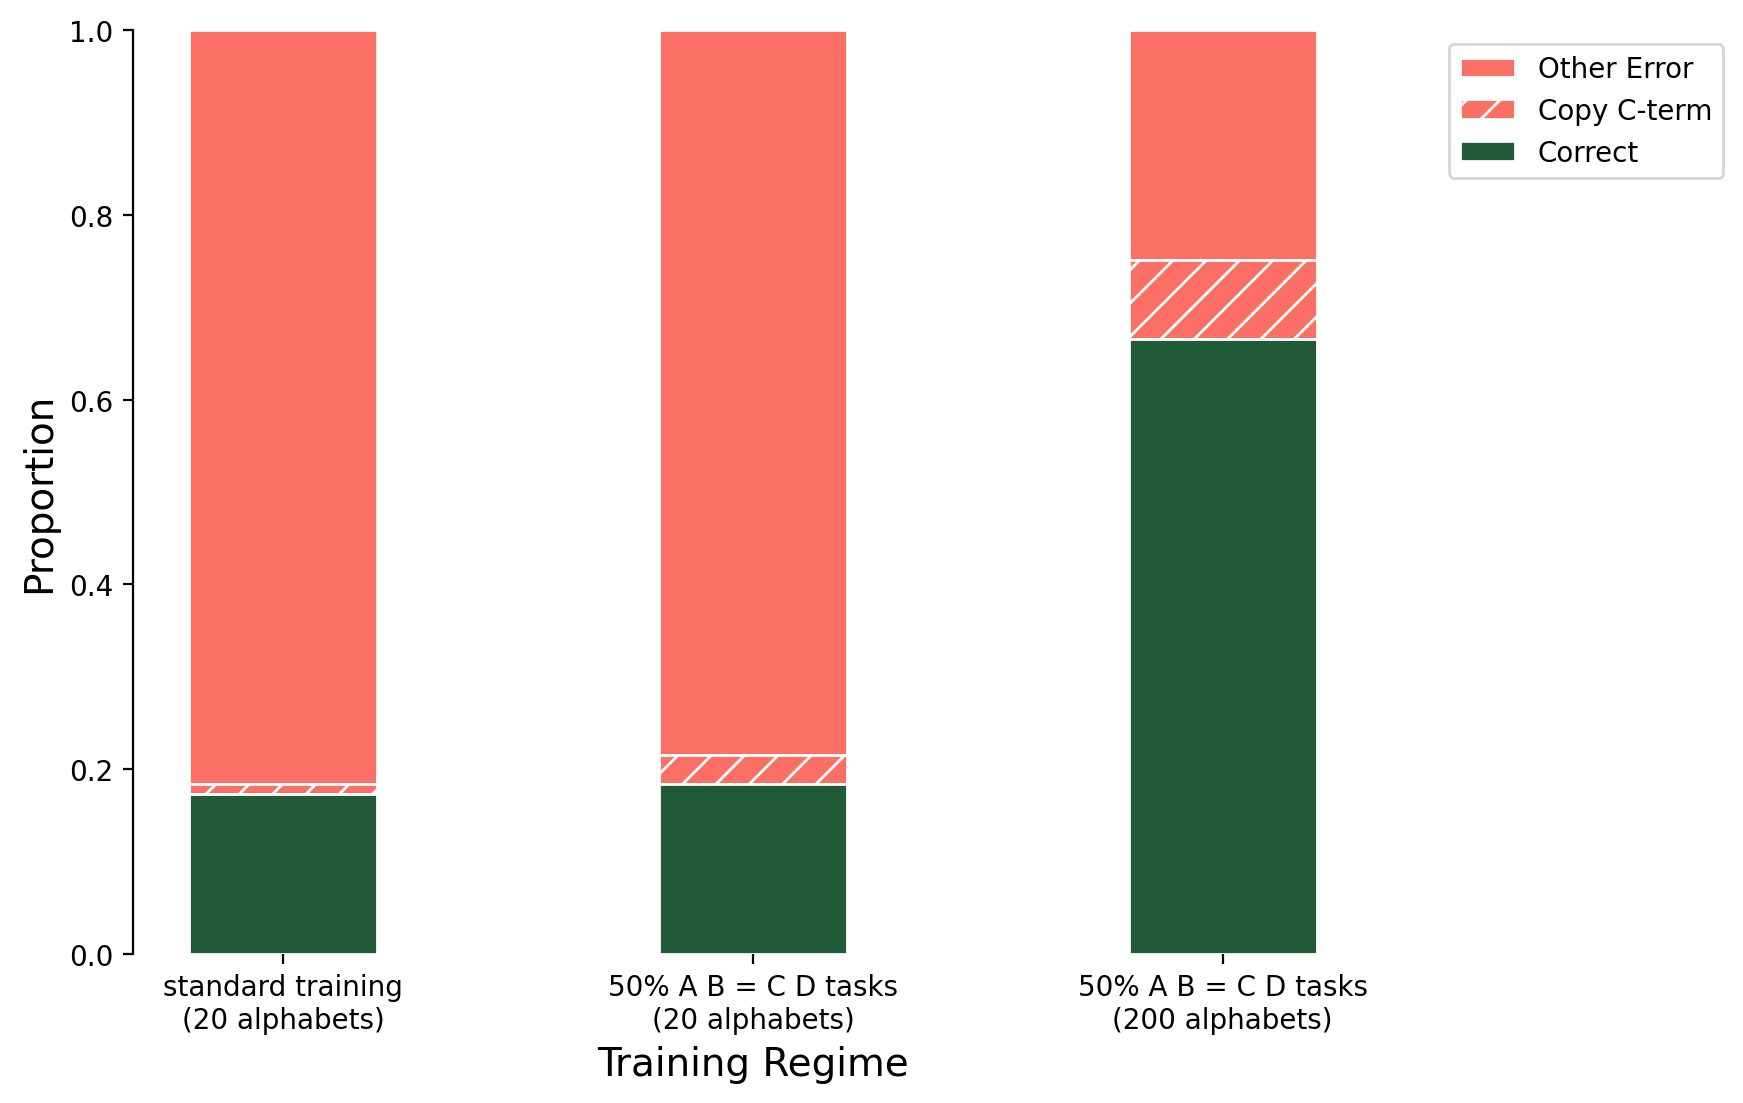

In [34]:
x = ['standard training\n(20 alphabets)', '50% A B = C D tasks\n(20 alphabets)', '50% A B = C D tasks\n(200 alphabets)']
correct = [unstruct_pred.correct.mean(), copy20_pred.correct.mean(), copy200_pred.correct.mean()]
copy_error = [unstruct_pred.copy_input.mean(), copy20_pred.copy_input.mean(), copy200_pred.copy_input.mean()]
other_error = [1 - c - cpe for c, cpe in zip(correct, copy_error)]

# Aesthetic color selection
color_correct = "#205A36"   # Soft Green
color_err = "#FC6F65"  # Vibrant Red

fig, ax = plt.subplots(figsize=(8,6))

# Calculate bottom for the third layer
bottom_3 = [c + cpe for c, cpe in zip(correct, copy_error)]

# Add diagonal stripes (hatch) to differentiate other errors
ax.bar(x, other_error, bottom=bottom_3, color=color_err, 
         label='Other Error', edgecolor='white', width=0.4)

ax.bar(x, copy_error, bottom=correct, 
        color=color_err, label='Copy C-term', edgecolor='white', hatch='//', width=0.4)

# Create the stacked bars
ax.bar(x, correct, color=color_correct, label='Correct', edgecolor='white', width=0.4)

# Formatting
ax.set_xlabel('Training Regime', fontsize=14)
ax.set_ylabel('Proportion', fontsize=14)
ax.set_ylim((0,1))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Legend outside the plot

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
plt.show()

### Evaluate MLC on LLM testlets

In [7]:
dataloader = LetterStringDataLoader(
    mode="test", 
    data_dir="../data/letter-string-analogies/llm_test_data", 
    batch_size=BATCH_SIZE, 
    batching_method="random"
)

In [24]:
pred_20 = au.predict_dataset(dataloader, model_unstruct)
pred_copy_20 = au.predict_dataset(dataloader, model_copy)
pred_copy_200 = au.predict_dataset(dataloader, model_best)

Generating predictions: 4it [00:36,  9.22s/it]                       
Generating predictions: 4it [00:49, 12.36s/it]                       
Generating predictions: 4it [00:47, 11.88s/it]                       


In [28]:
def clean_pred_df(pred_df, model_name: str):
    cols_to_keep = ["model","A","B","C","D","testlet","alphabet","n_perm","transformation","query_length","distribution","pred", "correct"]
    pred_df["model"] = model_name
    pred_df["pred"] = pred_df["pred"].apply(lambda x: " ".join(x))
    pred_df["correct"] = pred_df["correct"].astype(int)
    return pred_df[cols_to_keep]

In [29]:
predictions = [pred_20, pred_copy_20, pred_copy_200]
model_names = ["nocopy_20", "copy_20", "copy_200"]

for pred, model_name in zip(predictions, model_names):
    df = clean_pred_df(pred, model_name)
    df.to_csv(f"predictions/llm_comparison/results_{model_name}.csv")